Goal of code: Take a 1-dimension initial heat distribution at t=0 and use the fast fourier transform to calculate the heat distribution at some later point in time. Then do the same thing except using the analytic solution that involves doing a discrete convolution. Time each of them. 

I will first use a benchmark, synthetic data, and apply my algorithms to see how they do and compare their speeds. Then I will try to up the anty by using real data.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
import time

### Benchmark

Code for FFT and direction convolution given $u_0, \alpha, dx, dt$

In [17]:
import numpy as np

def heat_green(u0, alpha, dt, dx):
    # uses Green's function to predict u(x,dt) given u(x,0). The idea is we are 
    # we are creating our diffusion kernel given dt and sliding it across the intial distribution 
    N = len(u0)
    u_next = np.zeros(N)
    # The Heat Kernel (Gaussian)
    kernel = np.exp(-np.square(np.arange(-N/2, N/2)*dx) / (4 * alpha**2 * dt))
    kernel /= np.sum(kernel) # Normalize
    
    
    #start timer
    start = time.perf_counter()

    # O(N^2) Double Loop
    for i in range(N):
        for j in range(N):
            u_next[i] += u0[j] * kernel[(i - j) % N]
    return u_next,(time.perf_counter() - start)


def heat_fft(u0, alpha, dt, dx):
    # FFT. Instead, now we are transforming the distribution to fourier space, multiplying it by the kernel,
    # then inverse tranforming to get the solution. The idea is that convolution is space is multiplication 
    # in fourier space. This should be faster than Green's function

    n = len(u0)
    start = time.perf_counter()
    # 1. FFT
    U_hat = np.fft.fft(u0)

    # 2. Frequency Domain Kernel
    k = np.fft.fftfreq(n, d=dx)
    kernel_hat = np.exp(-alpha**2 * (2 * np.pi * k)**2 * dt)
    
    # 3. Inverse FFT
    u_next = np.fft.ifft(U_hat * kernel_hat).real

    return u_next, (time.perf_counter() - start)


Now we will trying to generate our own temperature distribution using both functions. For an initial distribution: lets try $u(x,0) = x^{1/2}sin(x)$ on a rod $0 \leq x \leq L$ 

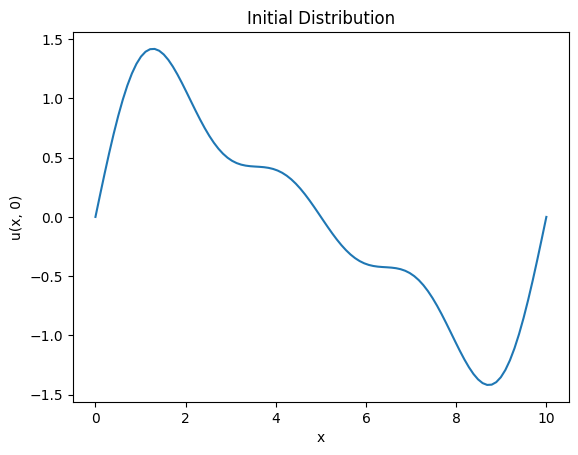

In [18]:
def initialdistribution(n, L):
    #create an initial distribution of n points
    
    # 1. Create the 't' grid (the horizontal axis)
    x = np.linspace(0, L, n)

    # 2. Apply the function to the grid
    #f_x =  x**0.5 * np.sin(x) * np.sin(np.pi * x / L)**2 #force periodicity
    
    # Sum of Fourier modes -- exactly periodic, evolves cleanly
    f_x = np.sin(2*np.pi*x/L) + 0.5*np.sin(4*np.pi*x/L) + 0.3*np.sin(6*np.pi*x/L)

    return f_x




x = np.linspace(0, 10, 100)
f_x = initialdistribution(100, 10)

plt.plot(x, f_x)
plt.xlabel("x")
plt.ylabel("u(x, 0)")
plt.title("Initial Distribution")
plt.show()



Prediction assesment:

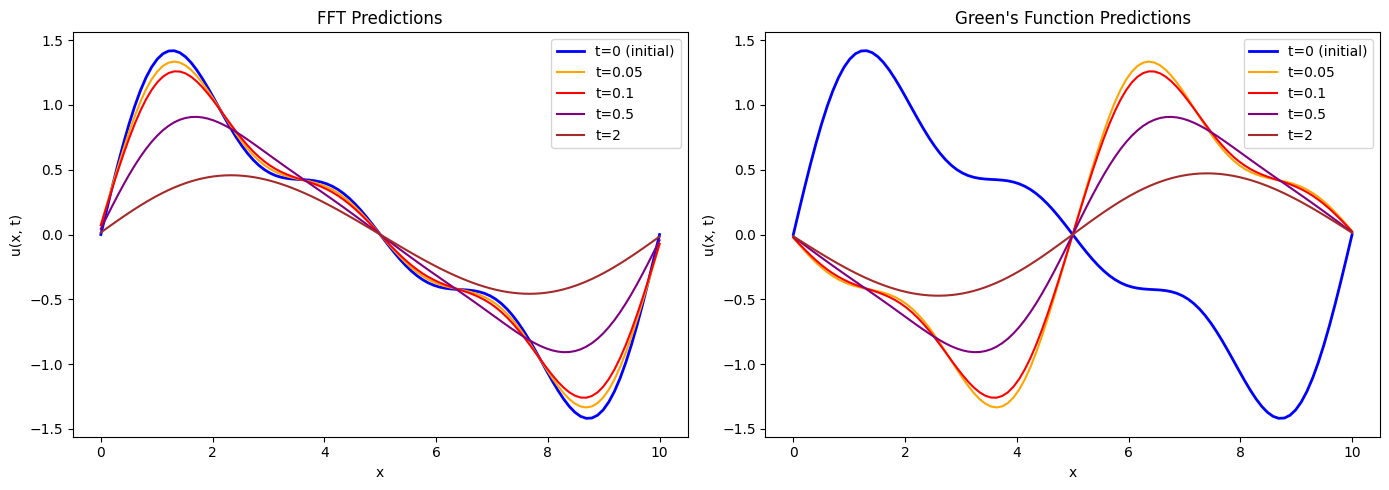

[(0.05, np.float64(1.3487287671106825)),
 (0.1, np.float64(1.3096739375568776)),
 (0.5, np.float64(1.0690420531709155)),
 (2, np.float64(0.5912404052094181))]

In [ ]:

def plotPred(t):
    #predictions for fft and green's function
    pred_green = [] 
    pred_fft = []
    diff = [] #difference in predictions
    L = 10 #length of rod

    alpha = 1 #arbitrary
    n = 100
    u0 = initialdistribution(n,L)
    dx = L/n

    for dt in t:
        predFFT =  heat_fft(u0,alpha,dt,dx)[0]
        predGreen = heat_green(u0,alpha,dt,dx)[0]
        pred_fft.append( predFFT)
        pred_green.append(predGreen)
        
        diff.append((dt,(sum(abs(predFFT-predGreen))/n)))

    #Graph them:

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    times = t
    colors = ['orange', 'red', 'purple', 'brown']

    # --- FFT ---
    ax1.plot(x, u0, 'b-', label='t=0 (initial)', linewidth=2)
    for i, t in enumerate(times):
        ax1.plot(x, pred_fft[i], color=colors[i], label=f't={t}')
    ax1.set_title("FFT Predictions")
    ax1.set_xlabel("x")
    ax1.set_ylabel("u(x, t)")
    ax1.legend()

    # --- Green's Function ---
    ax2.plot(x, u0, 'b-', label='t=0 (initial)', linewidth=2)
    for i, t in enumerate(times):
        ax2.plot(x, pred_green[i], color=colors[i], label=f't={t}')
    ax2.set_title("Green's Function Predictions")
    ax2.set_xlabel("x")
    ax2.set_ylabel("u(x, t)")
    ax2.legend()

    plt.tight_layout()
    plt.show()
    return diff

plotPred([.05,.1,.5,2])


- Notice that Green's function has the right predictions, but they are all shifted. This because the greens function kernel is only analytically equivalent to the Fourier transform on an infinite domain. For a smaller, shifted interval, and as time progresses, the Gaussian kernel's veriance will be too large in comparison to the interval. We could either made the interval bigger, or make green's function "periodic and bounded" like the FFT, by taking the IFFT of the kernel the FFT is using that. Besides this, the model of heat flow looks intuitively correct.

Lets update our Green's function and try again. Lets also look at prediction differences.

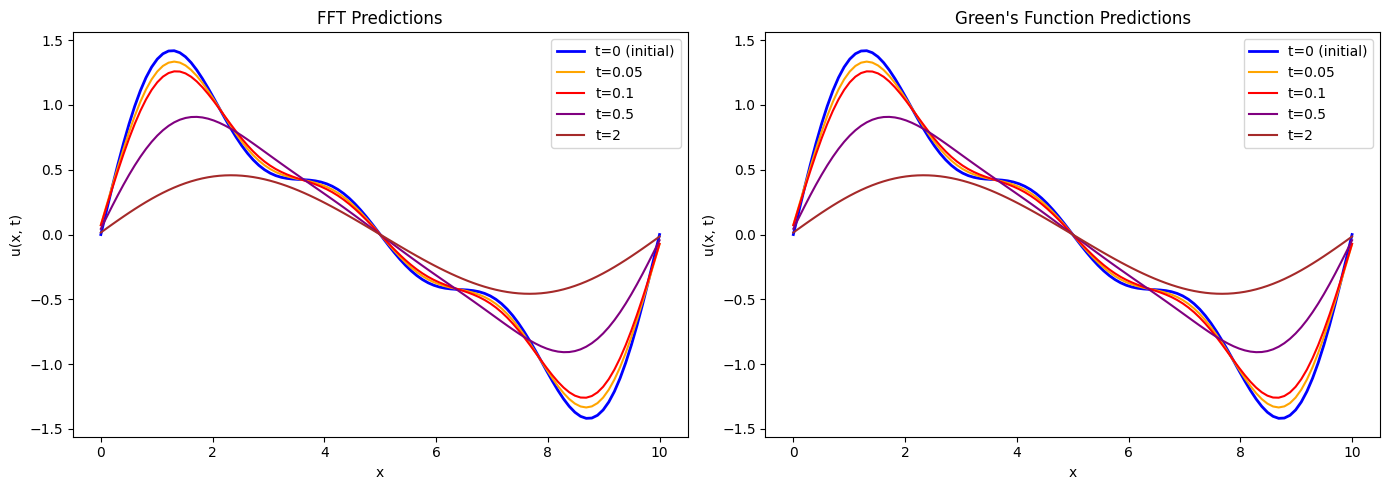

at time 0.05, average difference of 2.071606775011503e-16 in predictions
at time 0.1, average difference of 1.9918094951165698e-16 in predictions
at time 0.5, average difference of 1.444677710793485e-16 in predictions
at time 2, average difference of 1.1343356809412342e-16 in predictions


In [20]:

def heat_green(u0, alpha, dt, dx):
    # uses Green's function to predict u(x,dt) given u(x,0). The idea is we are 
    # we are creating our diffusion kernel given dt and sliding it across the intial distribution 
    N = len(u0)
    u_next = np.zeros(N)
    # The Heat Kernel (Gaussian)

    #Change here:
    # Build the exact same kernel FFT uses, but in real space
    k = np.fft.fftfreq(N, d=dx)
    kernel_hat = np.exp(-alpha**2 * (2 * np.pi * k)**2 * dt)
    kernel = np.fft.ifft(kernel_hat).real        # bring it back to real space

    #start timer
    start = time.perf_counter()

    # O(N^2) Double Loop
    for i in range(N):
        for j in range(N):
            u_next[i] += u0[j] * kernel[(i - j) % N]
    return u_next,(time.perf_counter() - start)


t = [0.05,.1,.5,2] #smaller time steps
diff = plotPred(t)
for d in diff:
    print(f"at time {d[0]}, average difference of {d[1]} in predictions")

Much better. Predictions are now almost identical, which is what we would expect since we are using the same kernel but just in different spaces (Frequency vs Space domain). Now we can compare time as our number of inputs $n$ increases. We should expect the FFT, which is performing multiplication in the frequency domain rather than convolution in the space domain to be faster, and for the difference to get much bigger as $n$ increases.

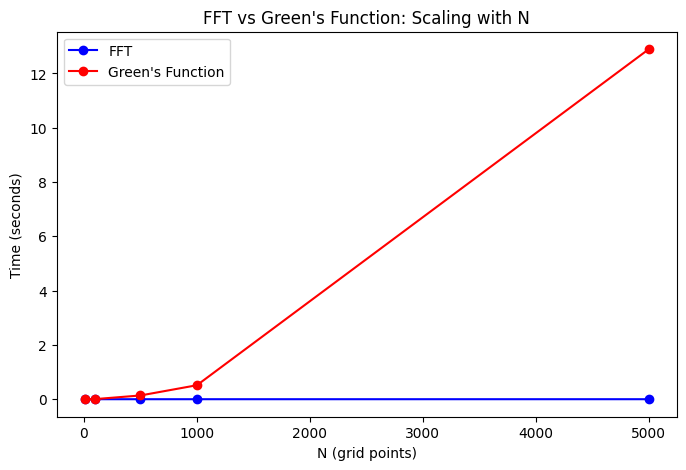

<Figure size 640x480 with 0 Axes>

for input n = 10, FFT is 0.8759125043815081 times faster
for input n = 100, FFT is 14.485642813317304 times faster
for input n = 500, FFT is 621.2032976937697 times faster
for input n = 1000, FFT is 1866.488362472287 times faster
for input n = 5000, FFT is 21421.247261150093 times faster


In [21]:
def plotTime(N):
    green_times= [] #prediction times for Green's function and FFT for each input size n
    fft_times = []
    diff = []

    alpha = 1 #arbitrary
    dt = 0.5 #fix dt
    L = 10

    for n in N:
        dx = L/n
        u0 = initialdistribution(n,L)
        timeGreen = heat_green(u0,alpha,dt,dx)[1]
        timeFFT = heat_fft(u0,alpha,dt,dx)[1]
        green_times.append(timeGreen)
        fft_times.append(timeFFT)
        diff.append((n,timeGreen,timeFFT))

    #Graph it

    plt.figure(figsize=(8, 5))
    plt.plot(N, fft_times, 'b-o', label='FFT')
    plt.plot(N, green_times, 'r-o', label="Green's Function")
    plt.xlabel('N (grid points)')
    plt.ylabel('Time (seconds)')
    plt.title("FFT vs Green's Function: Scaling with N")
    plt.legend()
    plt.show()

    plt.tight_layout()
    plt.show()
    return diff
    
diff = plotTime([10,100,500,1000, 5000])
for d in diff:
    print(f"for input n = {d[0]}, FFT is {(d[1]/d[2])} times faster")
    


This is exactly what was expected since the FFT algorithm is $O(nlogn)$ and a direct implementation of Green's function is $O(n^2)$. Now we can test on real data.

Data: https://www.kaggle.com/datasets/peijenlin/msl-m-rems-2-edr-v1.0
The REMS instrument is a meteorological package designed to
provide measurements of air and ground temperatures, wind speed
and direction, pressure, humidity and ultraviolet radiation.

This data set contains the raw unprocessed data stored in the REMS
internal memory, as received from telemetry and formatted
according to the REMS EDR SIS.

We will only need air temperatures and we will use them to try to model daily weather (temperature) on Mars

I downloaded one TAB file that represents sensor readings from one SOL (solar day on mars). We should be able to read it into a Panda dataframe and extract time stamps and temp readings from the many columns. a FMT file with provided giving us columns 2, 29, and 59 as time stamps and air temperature readings. I will take the average of them for accuracy.

### Real Data Preparation

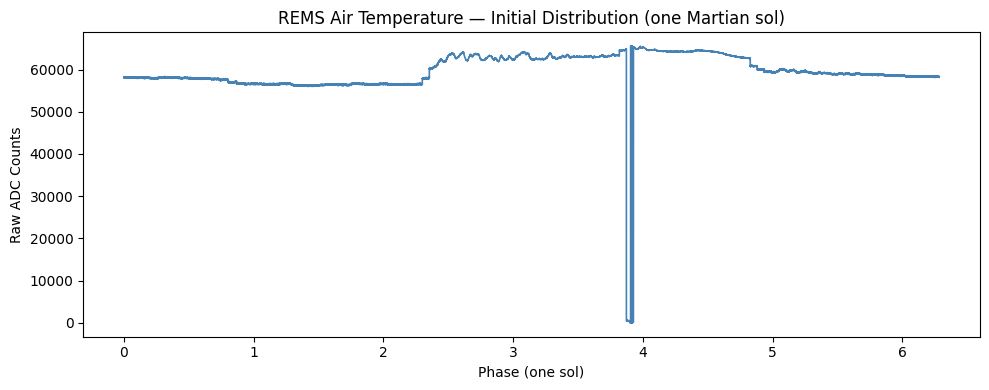

In [22]:

# .TAB files are fixed-width, not comma separated
df = pd.read_csv('data/clear/next/RME_606865298ESE23590000000ACQ____M1.TAB', header=None)

# Pull the three columns by index (0-based)
time_s  = df.iloc[:, 1]   # column 2  -> Time stamp
b1    = df.iloc[:, 28]  # column 29 -> B1_AIR_Temp
b2    = df.iloc[:, 58]  # column 59 -> B2_AIR_Temp

# just use boom 2
temp = b1
temp = temp.replace(-9999, np.nan).dropna()   # REMS uses -9999 for missing

# Sort by time just in case
df_clean = pd.DataFrame({'time': time_s, 'temp': temp}).sort_values('time')

u0_rems = df_clean['temp'].values

x = np.linspace(0, 2 * np.pi, len(u0_rems))



plt.figure(figsize=(10, 4))
plt.plot(x, u0_rems, color='steelblue', linewidth=1.2)
plt.xlabel("Phase (one sol)")
plt.ylabel("Raw ADC Counts")
plt.title("REMS Air Temperature — Initial Distribution (one Martian sol)")
plt.tight_layout()
plt.show()

Data cleaning: There are a couple of issues with this distribution although it should work. The distribution demonstrates periodicity and appears to be fairly continuous. we will ensure periodicity and set mean to 0.

In [23]:
n = len(u0_rems)
phase = np.linspace(0, 2*np.pi, n)

# Find the dip region -- values below a threshold
threshold = 35000  # adjust based on your signal
in_dip = u0_rems < threshold

# Find start and end index
dip_indices = np.where(in_dip)[0]
if len(dip_indices) > 0:
    dip_start = dip_indices[0]
    dip_end = dip_indices[-1]
    print(f"Dip from index {dip_start} to {dip_end}")
    print(f"Dip from phase {phase[dip_start]:.3f} to {phase[dip_end]:.3f}")
else:
    print("No dip found -- adjust threshold")

Dip from index 22006 to 22313
Dip from phase 3.872 to 3.926


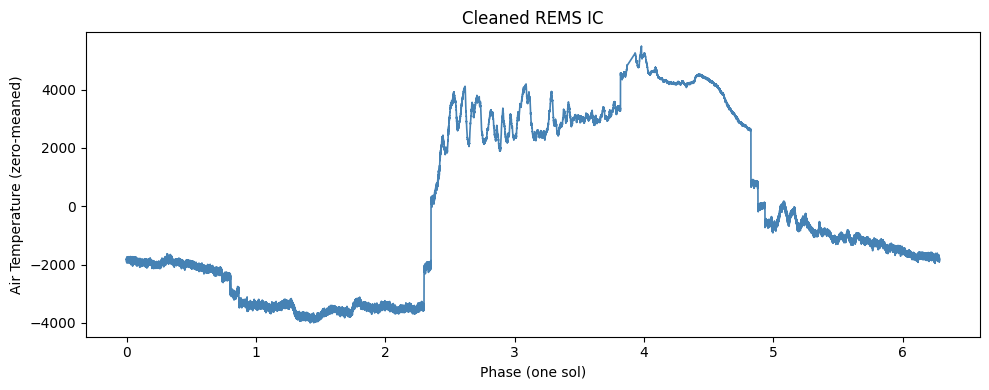

In [24]:

# --- Clean ---

temp_clean = u0_rems.copy().astype(float)

# Blank the artifact region around phase 4
n = len(temp_clean)
phase = np.linspace(0, 2*np.pi, n)
temp_clean[(phase > 3.87) & (phase < 3.93)] = np.nan

# Interpolate across the gap
temp_clean = pd.Series(temp_clean).interpolate(method='linear').values


# Force periodicity and zero-mean

# draw a line between endpoints
gap = temp_clean[-1] - temp_clean[0]
ramp = np.linspace(0, gap, n)

# Subtracting by that line so that we have equal endpoints
temp_clean = temp_clean - ramp

#set mean to 0 
temp_clean = temp_clean - temp_clean.mean()

u0_rems = temp_clean
#norm_factor = np.max(np.abs(u0_rems)) #save this for later use
#u0_rems_normalized = u0_rems / np.max(np.abs(u0_rems))



# --- Plot ---
plt.figure(figsize=(10, 4))
plt.plot(phase, u0_rems, color='steelblue', linewidth=1.2)
plt.xlabel("Phase (one sol)")
plt.ylabel("Air Temperature (zero-meaned)")
plt.title("Cleaned REMS IC")
plt.tight_layout()
plt.show()

Now that we have clean data, we have a proper $u(x,0)$. While we do not have an $x$ per se since this is all in time domain, this can still be modelled with diffusion since its periodic and has the proper boundary conditions. Now, we will take the next days distribution and call that $u(x,1)$. The goal will be to find the right $\alpha$ such that we can apply FFT or Green's function to obtain $u(x,1)$ from $u(x,0)$. We can do this in an iterative process that should be much faster with FFT. 

I will use two different sol pairs: sols (2084,2085) and (2358,2359). An interesting comparison is that in 2085/7, there was a massive dust storm going on, so we should expect the fitted $\alpha$ to be much different. Also notice that sol 2359 is not $u(x,1)$ since the best data came from the sol before it.

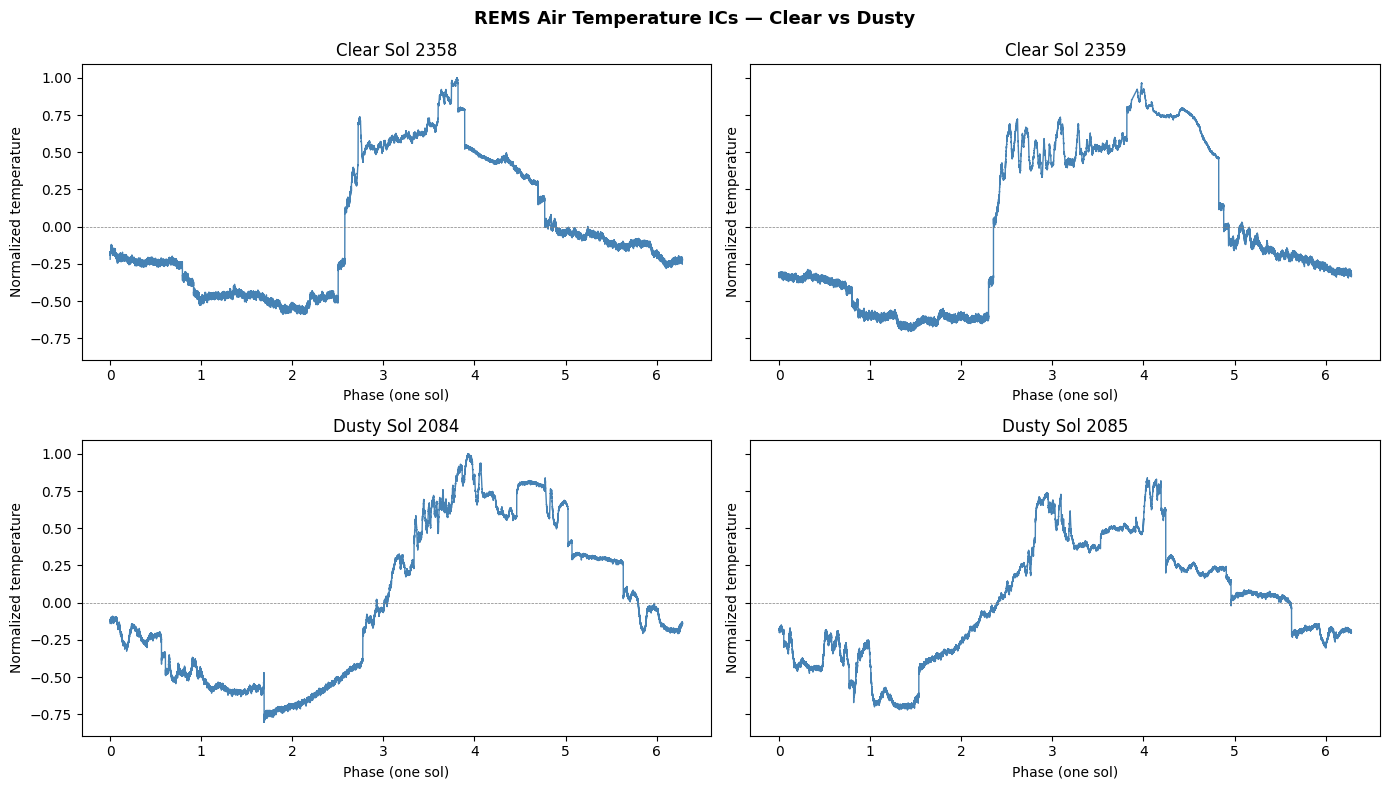

In [25]:
#Helper functions to read and clean data like we did with the first one

def load_rems_sol(filepath):
    
    # 1. Load
    df = pd.read_csv(filepath, header=None)

    # 2. Extract time and temperature columns
    time_s = df.iloc[:, 1]
    b1   = df.iloc[:, 28].replace(-9999, np.nan)
    b2   = df.iloc[:, 58].replace(-9999, np.nan)

    # 3. Get the temperature, just use boom 1 sensor, which i have found
    # to be more accurate from trial and error

    temp = b1

    #---------- Clean ---------------
    df_clean = pd.DataFrame({'time': time_s, 'temp': temp}).dropna().sort_values('time')
    temp_clean = df_clean['temp'].values.astype(float)

    # 4. Force periodicity
    n = len(temp_clean)
    gap = temp_clean[-1] - temp_clean[0]
    ramp = np.linspace(0, gap, n)
    temp_clean = temp_clean - ramp

    # 5. Zero-mean
    temp_clean = temp_clean - temp_clean.mean()

    return temp_clean

#Normalize each pair by max(sol N) for alpha fitting

u_clear_0 = load_rems_sol('data/clear/init/RME_606776523ESE23580000000ACQ____M1.TAB')
u_clear_1 = u0_rems #data prep done earlier
u_storm_0 = load_rems_sol('data/storm/init/RME_582452336ESE20840000000ACQ____M1.TAB')
u_storm_1 = load_rems_sol('data/storm/next/RME_582541111ESE20850000000ACQ____M1.TAB')

#Normalize
clear_norm_factor = np.max(np.abs(u_clear_0))
dust_norm_factor = np.max(np.abs(u_storm_0))

u_clear_0 /= clear_norm_factor
u_clear_1 /= clear_norm_factor
u_storm_0 /= dust_norm_factor
u_storm_1 /= dust_norm_factor


# --- Plot ---

sols = {
    'Clear Sol 2358':   u_clear_0,
    'Clear Sol 2359': u_clear_1,
    'Dusty Sol 2084':   u_storm_0,
    'Dusty Sol 2085': u_storm_1
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
axes = axes.flatten()

for ax, (title, u) in zip(axes, sols.items()):
    phase = np.linspace(0, 2*np.pi, len(u))
    ax.plot(phase, u, color='steelblue', linewidth=1.0)
    ax.set_title(title)
    ax.set_xlabel("Phase (one sol)")
    ax.set_ylabel("Normalized temperature")
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

plt.suptitle("REMS Air Temperature ICs — Clear vs Dusty", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


All sol data is really good (accurate readings), none of these must be cleaned further. Now I am going to fit an $\alpha$ for both both pairs using Green's function and FFT and time it

### Applying Green's function and FFT on data

Since this would take days for Green's function if we use all the data for each sol, I am going to downsize and interpolate which should preserve the shape but be faster to fit

In [26]:
def downsample(u, target_n=4096):
    return np.interp(np.linspace(0, 1, target_n),
                     np.linspace(0, 1, len(u)), u)

# Downsample all four sols
u_clear_0_ds = downsample(u_clear_0)
u_clear_1_ds = downsample(u_clear_1)
u_storm_0_ds = downsample(u_storm_0)
u_storm_1_ds = downsample(u_storm_1)

In [27]:
def fit_alpha(u0, u_target, dx, dt, method):
    #Mean Square Error
    def mse(alpha):
        #Get the prediction
        pred, _ = method(u0, alpha, dt, dx)
        if len(pred) != len(u_target):
            #Interpolate error interval
            pred = np.interp(np.linspace(0,1,len(u_target)),
                            np.linspace(0,1,len(pred)), pred)
            
        #Square the average error on the interval
        return np.mean((pred - u_target)**2)
    
    #Using an optimize from scipy
    result = minimize_scalar(mse, bounds=(0.01, 10.0), method='bounded')
    return result.x


dt = 1.0 # dt = 1 sol
pairs = {
    'Clear (Sol 2358 to 2359)': (u_clear_0_ds, u_clear_1_ds),
    'Dusty (Sol 2084 to 2085)': (u_storm_0_ds, u_storm_1_ds)
}

# --------- Applying alpha fit and timing it ---------------
for condition, (u0, u1) in pairs.items():
    dx = 2 * np.pi / len(u0)
    rows = []

    for method_name, method in [('FFT', heat_fft), ('Greens', heat_green)]:

        start = time.perf_counter() #Start timer
        alpha = fit_alpha(u0, u1, dx, dt, method) #fit alpha
        elapsed = time.perf_counter() - start #end timer

        #store results
        rows.append({'Method': method_name,
                     'Alpha': round(alpha, 4),
                     'Time (s)': round(elapsed, 3)})

    #Create a table:
    df = pd.DataFrame(rows).set_index('Method')
    df['FFT vs Green'] = round(rows[1]['Time (s)'] / df['Time (s)'], 1)
    
    print(f"\n{condition}")
    print(df.to_string())
    print("-" * 40)


Clear (Sol 2358 to 2359)
         Alpha  Time (s)  FFT vs Green
Method                                
FFT     0.1655     0.010        9161.8
Greens  0.1655    91.618           1.0
----------------------------------------

Dusty (Sol 2084 to 2085)
         Alpha  Time (s)  FFT vs Green
Method                                
FFT     0.7163     0.002       25116.0
Greens  0.7163    50.232           1.0
----------------------------------------


fitted $\alpha$ s are in exact agreement by algorithm, which make sense. However, FFT is way faster. Also notice how the alpha for the storm pair is much higher, much makes sense since there is less solar radiation in the atmosphere that is adding new heat into th system. Now lets try to visualize how good each prediction is

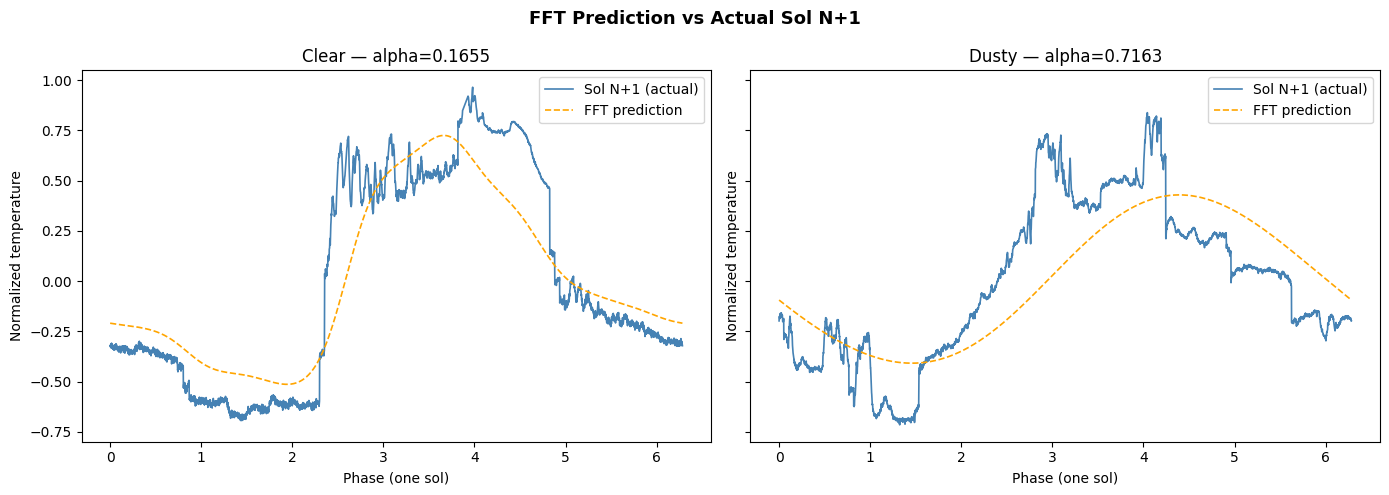

In [28]:

#Overlay prediction onto Sol N+1

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

#Each Sol pair with fitted alpha value
pairs = [
    ('Clear', u_clear_0_ds, u_clear_1_ds, 0.1655),
    ('Dusty', u_storm_0_ds, u_storm_1_ds, 0.7163)
]

for ax, (condition, u0, u1, alpha) in zip(axes, pairs):
    dx = 2 * np.pi / len(u0)
    phase = np.linspace(0, 2 * np.pi, len(u0))

    pred, _ = heat_fft(u0, alpha, dt, dx)

    ax.plot(phase, u1,   color='steelblue', linewidth=1.2, label='Sol N+1 (actual)')
    ax.plot(phase, pred, color='orange',    linewidth=1.2, label='FFT prediction', linestyle='--')
    ax.set_title(f"{condition} — alpha={alpha:.4f}")
    ax.set_xlabel("Phase (one sol)")
    ax.set_ylabel("Normalized temperature")
    ax.legend()

plt.suptitle("FFT Prediction vs Actual Sol N+1", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Looking at the graphs, we see that the clear day sols had far less error compared to the dust storm pair. Which may be interpretable. Also, it does not look like diffusion modelled the storm pair very well at all, which could be by chance or other reasons. I will go into this more in the paper